<a href="https://colab.research.google.com/github/ignaciomorenobarria21-a11y/Machine_Learning/blob/main/Sesion_07_Seleccion_Variables.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎓 Fundamentos de Machine Learning

## Sesión 7: Selección de Variables

**Máster en Formación Permanente en Inteligencia Artificial para el Sector Financiero**  
Universidad Internacional de Valencia · Edición Octubre 2025/26

---

📅 **Fecha:** 29 de enero de 2026  
⏱️ **Duración:** ~100 minutos  
👨‍🏫 **Profesor:** Jaume Antolí Plaza

## 1. Introducción: ¿Por Qué Seleccionar Variables?

En las sesiones anteriores hemos trabajado con **4 features** seleccionadas manualmente (RSI, STOCH, WILLR, CCI). Pero nuestro dataset contiene **cientos de indicadores técnicos**.

```
EL PROBLEMA DE MUCHAS FEATURES
═══════════════════════════════════════════════════════════════════

    4 features                      400+ features
    ┌─┬─┬─┬─┐                       ┌─┬─┬─┬─┬─┬─┬─┬─┬─┬─┬─┬─┬─┬─┬─┐...
    │ │ │ │ │                       │ │ │ │ │ │ │ │ │ │ │ │ │ │ │ │
    └─┴─┴─┴─┘                       └─┴─┴─┴─┴─┴─┴─┴─┴─┴─┴─┴─┴─┴─┴─┘

    ✅ Rápido                       ❌ Maldición de la dimensionalidad
    ✅ Interpretable                ❌ Ruido > Señal
    ✅ Menos sobreajuste            ❌ Mayor riesgo de sobreajuste
                                    ❌ Entrenamiento lento
                                    ❌ Multicolinealidad
```

### La Maldición de la Dimensionalidad

```
¿POR QUÉ MÁS FEATURES PUEDE SER PEOR?
═══════════════════════════════════════════════════════════════════

    Imagina buscar patrones en un espacio:

    2D (2 features)           3D (3 features)         100D (100 features)
    ┌─────────────┐           
    │  •  •       │           Los puntos se           Los puntos están
    │    •  •     │           dispersan más           TAN dispersos que
    │  •     •    │           en el espacio           encontrar patrones
    │       •     │                                   reales es casi
    └─────────────┘                                   imposible
    
    Datos "densos"            Datos dispersos         Datos muy dispersos
    → Patrones claros         → Patrones difusos      → Solo ruido


    Además, con muchas features:
    
    • Es FÁCIL encontrar patrones ESPURIOS (casualidad)
    • El modelo memoriza ruido en lugar de aprender señales
    • El rendimiento en datos nuevos es PEOR
```

### Multicolinealidad: Features Redundantes

```
MULTICOLINEALIDAD = FEATURES QUE DICEN LO MISMO
═══════════════════════════════════════════════════════════════════

    Ejemplo con indicadores técnicos:

    RSI_14  ←──── Correlación 0.98 ────→  RSI_15
    
    Stoch_10 ←─── Correlación 0.95 ────→  Stoch_12
    
    WILLR_20 ←─── Correlación 0.99 ────→  WILLR_21


    Problemas:
    
    • Información DUPLICADA → No aportan nada nuevo
    • El modelo "reparte" importancia entre features similares
    • Dificulta interpretar qué variables son realmente útiles
    • Puede causar inestabilidad en algunos algoritmos


    Solución: Quedarnos con UNA feature de cada grupo de correlacionadas
```

## 2. Tipos de Métodos de Selección

Existen tres familias principales de métodos:

```
MÉTODOS DE SELECCIÓN DE VARIABLES
═══════════════════════════════════════════════════════════════════

┌─────────────────────────────────────────────────────────────────┐
│  1. FILTRO (Filter Methods)                                    │
├─────────────────────────────────────────────────────────────────┤
│                                                                 │
│    Features ──► Ranking estadístico ──► Top N                  │
│                                                                 │
│    Ejemplos: Correlación, Mutual Information, ANOVA            │
│                                                                 │
│    ✅ Muy rápido                                                │
│    ✅ Simple de implementar                                     │
│    ❌ Ignora interacciones entre features                       │
│    ❌ No considera el modelo final                              │
└─────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────┐
│  2. WRAPPER (Wrapper Methods)                                  │
├─────────────────────────────────────────────────────────────────┤
│                                                                 │
│    ┌────────────────────────────────────────┐                   │
│    │  Probar subconjunto ──► Entrenar ──►  │ Loop              │
│    │                         Evaluar  ─────┘                    │
│    └────────────────────────────────────────┘                   │
│                                                                 │
│    Ejemplos: RFE (Recursive Feature Elimination),              │
│              Forward Selection, Backward Elimination            │
│                                                                 │
│    ✅ Encuentra combinaciones óptimas                           │
│    ❌ MUY lento (entrena muchos modelos)                        │
│    ❌ Alto riesgo de sobreajuste                                │
└─────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────┐
│  3. EMBEDDED (Métodos Integrados)                              │
├─────────────────────────────────────────────────────────────────┤
│                                                                 │
│    La selección ocurre DURANTE el entrenamiento                 │
│                                                                 │
│    Ejemplos:                                                    │
│    • Random Forest → feature_importances_                       │
│    • Lasso → coeficientes que se vuelven 0                      │
│    • XGBoost → importancia por ganancia                         │
│                                                                 │
│    ✅ Balance entre velocidad y calidad                         │
│    ✅ Considera interacciones                                   │
│    ✅ Específico para el tipo de modelo                         │
└─────────────────────────────────────────────────────────────────┘
```

### Lo Que Haremos Hoy

```
PLAN DE LA SESIÓN
═══════════════════════════════════════════════════════════════════

    1. Reducir MULTICOLINEALIDAD (umbral 0.99)
       → Resultado: N features supervivientes
       → Este N será nuestro número objetivo

    2. Aplicar 3 métodos alternativos para seleccionar N features:
       
       • RF Importance (RandomForestRegressor)
       • SelectKBest con mutual_info_regression
       • SelectKBest con r_regression

    3. Comparar los 4 conjuntos + todas las features:
       
       • Entrenar RF clasificador con cada conjunto
       • Medir tiempos de entrenamiento
       • Comparar curvas de equity
```

### Nota Importante: Target para Selección vs Target para Clasificación

```
¿QUÉ TARGET USAMOS?
═══════════════════════════════════════════════════════════════════

    PARA SELECCIONAR FEATURES → Target_Return (continuo)
    ─────────────────────────────────────────────────────
    
    Target_Return = +0.0052  →  Nos dice: SUBE + magnitud GRANDE
    Target_Return = +0.0003  →  Nos dice: SUBE + magnitud PEQUEÑA  
    Target_Return = -0.0041  →  Nos dice: BAJA + magnitud GRANDE
    
    → Más INFORMATIVO para encontrar features predictivas


    PARA ENTRENAR EL MODELO → Target_Direccion (discreto)
    ─────────────────────────────────────────────────────
    
    Target_Direccion = 1  →  Solo nos dice: SUBE
    Target_Direccion = 0  →  Solo nos dice: BAJA
    
    → Adecuado para clasificación binaria


    IDEA CLAVE:
    ───────────
    El target continuo discrimina mejor porque no es lo mismo
    una subida del 0.01% que una del 2%. Ambas son "SUBE" en
    el target discreto, pero muy diferentes en importancia.
```

## 3. Cargar Librerías y Datos

In [ ]:
# ============================================================
# IMPORTAR LIBRERÍAS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

# Scikit-learn
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.feature_selection import SelectKBest, mutual_info_regression, r_regression

# Configuración de visualización
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

# Mostrar todas las columnas en pandas
pd.set_option('display.max_columns', None)

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


In [ ]:
# ============================================================
# CARGA DE DATOS
# Dataset preparado en la Sesión 1 con indicadores técnicos
# ============================================================

# Cargar el dataset directamente desde Google Drive
url = 'https://drive.google.com/uc?id=13vNdqTBl4xZurr1jbcoVHCy9PinJosiL'
df = pd.read_csv(url, index_col=0, parse_dates=True)

print(f"Dataset cargado: {len(df):,} filas")
print(f"Período: {df.index[0].strftime('%Y-%m-%d')} a {df.index[-1].strftime('%Y-%m-%d')}")
print(f"Columnas totales: {len(df.columns)}")
df.head()

Dataset cargado: 2,489 filas
Período: 2010-05-25 a 2019-12-30
Columnas totales: 501


,Open,High,Low,Close,RSI_2,STOCH_2,WILLR_2,CCI_2,ADX_2,RSI_3,STOCH_3,WILLR_3,CCI_3,ADX_3,RSI_4,STOCH_4,WILLR_4,CCI_4,ADX_4,RSI_5,STOCH_5,WILLR_5,CCI_5,ADX_5,RSI_6,STOCH_6,WILLR_6,CCI_6,ADX_6,RSI_7,STOCH_7,WILLR_7,CCI_7,ADX_7,RSI_8,STOCH_8,WILLR_8,CCI_8,ADX_8,RSI_9,STOCH_9,WILLR_9,CCI_9,ADX_9,RSI_10,STOCH_10,WILLR_10,CCI_10,ADX_10,RSI_11,STOCH_11,WILLR_11,CCI_11,ADX_11,RSI_12,STOCH_12,WILLR_12,CCI_12,ADX_12,RSI_13,STOCH_13,WILLR_13,CCI_13,ADX_13,RSI_14,STOCH_14,WILLR_14,CCI_14,ADX_14,RSI_15,STOCH_15,WILLR_15,CCI_15,ADX_15,RSI_16,STOCH_16,WILLR_16,CCI_16,ADX_16,RSI_17,STOCH_17,WILLR_17,CCI_17,ADX_17,RSI_18,STOCH_18,WILLR_18,CCI_18,ADX_18,RSI_19,STOCH_19,WILLR_19,CCI_19,ADX_19,RSI_20,STOCH_20,WILLR_20,CCI_20,ADX_20,RSI_21,STOCH_21,WILLR_21,CCI_21,ADX_21,RSI_22,STOCH_22,WILLR_22,CCI_22,ADX_22,RSI_23,STOCH_23,WILLR_23,CCI_23,ADX_23,RSI_24,STOCH_24,WILLR_24,CCI_24,ADX_24,RSI_25,STOCH_25,WILLR_25,CCI_25,ADX_25,RSI_26,STOCH_26,WILLR_26,CCI_26,ADX_26,RSI_27,STOCH_27,WILLR_27,CCI_27,ADX_27,RSI_28,STOCH_28,WILLR_28,CCI_28,ADX_28,RSI_29,STOCH_29,WILLR_29,CCI_29,ADX_29,RSI_30,STOCH_30,WILLR_30,CCI_30,ADX_30,RSI_31,STOCH_31,WILLR_31,CCI_31,ADX_31,RSI_32,STOCH_32,WILLR_32,CCI_32,ADX_32,RSI_33,STOCH_33,WILLR_33,CCI_33,ADX_33,RSI_34,STOCH_34,WILLR_34,CCI_34,ADX_34,RSI_35,STOCH_35,WILLR_35,CCI_35,ADX_35,RSI_36,STOCH_36,WILLR_36,CCI_36,ADX_36,RSI_37,STOCH_37,WILLR_37,CCI_37,ADX_37,RSI_38,STOCH_38,WILLR_38,CCI_38,ADX_38,RSI_39,STOCH_39,WILLR_39,CCI_39,ADX_39,RSI_40,STOCH_40,WILLR_40,CCI_40,ADX_40,RSI_41,STOCH_41,WILLR_41,CCI_41,ADX_41,RSI_42,STOCH_42,WILLR_42,CCI_42,ADX_42,RSI_43,STOCH_43,WILLR_43,CCI_43,ADX_43,RSI_44,STOCH_44,WILLR_44,CCI_44,ADX_44,RSI_45,STOCH_45,WILLR_45,CCI_45,ADX_45,RSI_46,STOCH_46,WILLR_46,CCI_46,ADX_46,RSI_47,STOCH_47,WILLR_47,CCI_47,ADX_47,RSI_48,STOCH_48,WILLR_48,CCI_48,ADX_48,RSI_49,STOCH_49,WILLR_49,CCI_49,ADX_49,RSI_50,STOCH_50,WILLR_50,CCI_50,ADX_50,RSI_51,STOCH_51,WILLR_51,CCI_51,ADX_51,RSI_52,STOCH_52,WILLR_52,CCI_52,ADX_52,RSI_53,STOCH_53,WILLR_53,CCI_53,ADX_53,RSI_54,STOCH_54,WILLR_54,CCI_54,ADX_54,RSI_55,STOCH_55,WILLR_55,CCI_55,ADX_55,RSI_56,STOCH_56,WILLR_56,CCI_56,ADX_56,RSI_57,STOCH_57,WILLR_57,CCI_57,ADX_57,RSI_58,STOCH_58,WILLR_58,CCI_58,ADX_58,RSI_59,STOCH_59,WILLR_59,CCI_59,ADX_59,RSI_60,STOCH_60,WILLR_60,CCI_60,ADX_60,RSI_61,STOCH_61,WILLR_61,CCI_61,ADX_61,RSI_62,STOCH_62,WILLR_62,CCI_62,ADX_62,RSI_63,STOCH_63,WILLR_63,CCI_63,ADX_63,RSI_64,STOCH_64,WILLR_64,CCI_64,ADX_64,RSI_65,STOCH_65,WILLR_65,CCI_65,ADX_65,RSI_66,STOCH_66,WILLR_66,CCI_66,ADX_66,RSI_67,STOCH_67,WILLR_67,CCI_67,ADX_67,RSI_68,STOCH_68,WILLR_68,CCI_68,ADX_68,RSI_69,STOCH_69,WILLR_69,CCI_69,ADX_69,RSI_70,STOCH_70,WILLR_70,CCI_70,ADX_70,RSI_71,STOCH_71,WILLR_71,CCI_71,ADX_71,RSI_72,STOCH_72,WILLR_72,CCI_72,ADX_72,RSI_73,STOCH_73,WILLR_73,CCI_73,ADX_73,RSI_74,STOCH_74,WILLR_74,CCI_74,ADX_74,RSI_75,STOCH_75,WILLR_75,CCI_75,ADX_75,RSI_76,STOCH_76,WILLR_76,CCI_76,ADX_76,RSI_77,STOCH_77,WILLR_77,CCI_77,ADX_77,RSI_78,STOCH_78,WILLR_78,CCI_78,ADX_78,RSI_79,STOCH_79,WILLR_79,CCI_79,ADX_79,RSI_80,STOCH_80,WILLR_80,CCI_80,ADX_80,RSI_81,STOCH_81,WILLR_81,CCI_81,ADX_81,RSI_82,STOCH_82,WILLR_82,CCI_82,ADX_82,RSI_83,STOCH_83,WILLR_83,CCI_83,ADX_83,RSI_84,STOCH_84,WILLR_84,CCI_84,ADX_84,RSI_85,STOCH_85,WILLR_85,CCI_85,ADX_85,RSI_86,STOCH_86,WILLR_86,CCI_86,ADX_86,RSI_87,STOCH_87,WILLR_87,CCI_87,ADX_87,RSI_88,STOCH_88,WILLR_88,CCI_88,ADX_88,RSI_89,STOCH_89,WILLR_89,CCI_89,ADX_89,RSI_90,STOCH_90,WILLR_90,CCI_90,ADX_90,RSI_91,STOCH_91,WILLR_91,CCI_91,ADX_91,RSI_92,STOCH_92,WILLR_92,CCI_92,ADX_92,RSI_93,STOCH_93,WILLR_93,CCI_93,ADX_93,RSI_94,STOCH_94,WILLR_94,CCI_94,ADX_94,RSI_95,STOCH_95,WILLR_95,CCI_95,ADX_95,RSI_96,STOCH_96,WILLR_96,CCI_96,ADX_96,RSI_97,STOCH_97,WILLR_97,CCI_97,ADX_97,RSI_98,STOCH_98,WILLR_98,CCI_98,ADX_98,RSI_99,STOCH_99,WILLR_99,CCI_99,ADX_99,RSI_100,STOCH_100,WILLR_100,CCI_100,ADX_100,Target_Return,Target_Direccion
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,

In [ ]:
# ============================================================
# EXPLORAR LAS COLUMNAS DISPONIBLES
# ============================================================

# Identificar columnas por tipo
cols_ohlc = ['Open', 'High', 'Low', 'Close']
cols_target = ['Target_Return', 'Target_Direccion']

# El resto son features (indicadores técnicos)
cols_features = [col for col in df.columns if col not in cols_ohlc + cols_target]

print("=" * 60)
print("ESTRUCTURA DEL DATASET")
print("=" * 60)
print(f"\n📈 Columnas OHLC:      {len(cols_ohlc)}")
print(f"🎯 Columnas Target:    {len(cols_target)}")
print(f"📊 Columnas Features:  {len(cols_features)}")
print(f"\n   Total columnas:     {len(df.columns)}")

print("\n" + "=" * 60)
print("TIPOS DE INDICADORES (primeros ejemplos)")
print("=" * 60)

# Agrupar features por prefijo
prefijos = {}
for col in cols_features:
    prefijo = col.split('_')[0]
    if prefijo not in prefijos:
        prefijos[prefijo] = []
    prefijos[prefijo].append(col)

for prefijo, cols in sorted(prefijos.items(), key=lambda x: -len(x[1]))[:10]:
    print(f"\n   {prefijo}: {len(cols)} variantes")
    print(f"      Ejemplos: {cols[:3]}")

if len(prefijos) > 10:
    print(f"\n   ... y {len(prefijos) - 10} tipos más de indicadores")

ESTRUCTURA DEL DATASET

📈 Columnas OHLC:      4
🎯 Columnas Target:    2
📊 Columnas Features:  495

   Total columnas:     501

TIPOS DE INDICADORES (primeros ejemplos)

   RSI: 99 variantes
      Ejemplos: ['RSI_2', 'RSI_3', 'RSI_4']

   STOCH: 99 variantes
      Ejemplos: ['STOCH_2', 'STOCH_3', 'STOCH_4']

   WILLR: 99 variantes
      Ejemplos: ['WILLR_2', 'WILLR_3', 'WILLR_4']

   CCI: 99 variantes
      Ejemplos: ['CCI_2', 'CCI_3', 'CCI_4']

   ADX: 99 variantes
      Ejemplos: ['ADX_2', 'ADX_3', 'ADX_4']


In [ ]:
# ============================================================
# PREPARAR DATOS
# ============================================================

# Eliminar filas con NaN
df_clean = df.dropna().copy()

print(f"Filas originales:  {len(df):,}")
print(f"Filas después de dropna: {len(df_clean):,}")
print(f"Filas eliminadas:  {len(df) - len(df_clean):,}")

# Separar features y targets
X_all = df_clean[cols_features]
y_return = df_clean['Target_Return']      # Para selección de features
y_direccion = df_clean['Target_Direccion'] # Para clasificación

print(f"\n📊 Dimensiones de X (todas las features): {X_all.shape}")
print(f"🎯 Dimensiones de y_return: {y_return.shape}")
print(f"🎯 Dimensiones de y_direccion: {y_direccion.shape}")

Filas originales:  2,489
Filas después de dropna: 2,489
Filas eliminadas:  0

📊 Dimensiones de X (todas las features): (2489, 495)
🎯 Dimensiones de y_return: (2489,)
🎯 Dimensiones de y_direccion: (2489,)


## 4. Método 1: Reducir Multicolinealidad

El primer paso es eliminar features altamente correlacionadas entre sí. Usaremos un umbral de **0.99**.

```
ALGORITMO PARA REDUCIR MULTICOLINEALIDAD
═══════════════════════════════════════════════════════════════════

    1. Calcular matriz de correlación entre TODAS las features
    2. Para cada par con |correlación| > 0.99:
       → Eliminar UNA de las dos (la segunda que aparece)
    3. Resultado: features "independientes"

    Nota: Este método NO mira el target, solo las relaciones
          entre features.
```

In [ ]:
# ============================================================
# CALCULAR MATRIZ DE CORRELACIÓN
# ============================================================

print("Calculando matriz de correlación...")
print(f"(Esto puede tardar unos segundos con {X_all.shape[1]} features)")

inicio = time.time()
corr_matrix = X_all.corr().abs()
tiempo_corr = time.time() - inicio

print(f"\n✅ Matriz calculada en {tiempo_corr:.2f} segundos")
print(f"   Dimensiones: {corr_matrix.shape}")

Calculando matriz de correlación...
(Esto puede tardar unos segundos con 495 features)

✅ Matriz calculada en 4.20 segundos
   Dimensiones: (495, 495)


In [ ]:
# ============================================================
# ELIMINAR FEATURES ALTAMENTE CORRELACIONADAS
# ============================================================

umbral_corr = 0.99

# Crear máscara triangular superior (para no contar pares dos veces)
upper_triangle = np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)

# Encontrar features a eliminar
features_a_eliminar = set()

for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        if corr_matrix.iloc[i, j] > umbral_corr:
            # Eliminar la segunda feature del par
            features_a_eliminar.add(corr_matrix.columns[j])

# Features supervivientes
features_multicol = [col for col in X_all.columns if col not in features_a_eliminar]

print("=" * 60)
print(f"REDUCCIÓN DE MULTICOLINEALIDAD (umbral = {umbral_corr})")
print("=" * 60)
print(f"\n   Features originales:    {len(X_all.columns)}")
print(f"   Features eliminadas:    {len(features_a_eliminar)}")
print(f"   Features supervivientes: {len(features_multicol)}")
print(f"\n   → N = {len(features_multicol)} será nuestro número objetivo")

REDUCCIÓN DE MULTICOLINEALIDAD (umbral = 0.99)

   Features originales:    495
   Features eliminadas:    455
   Features supervivientes: 40

   → N = 40 será nuestro número objetivo


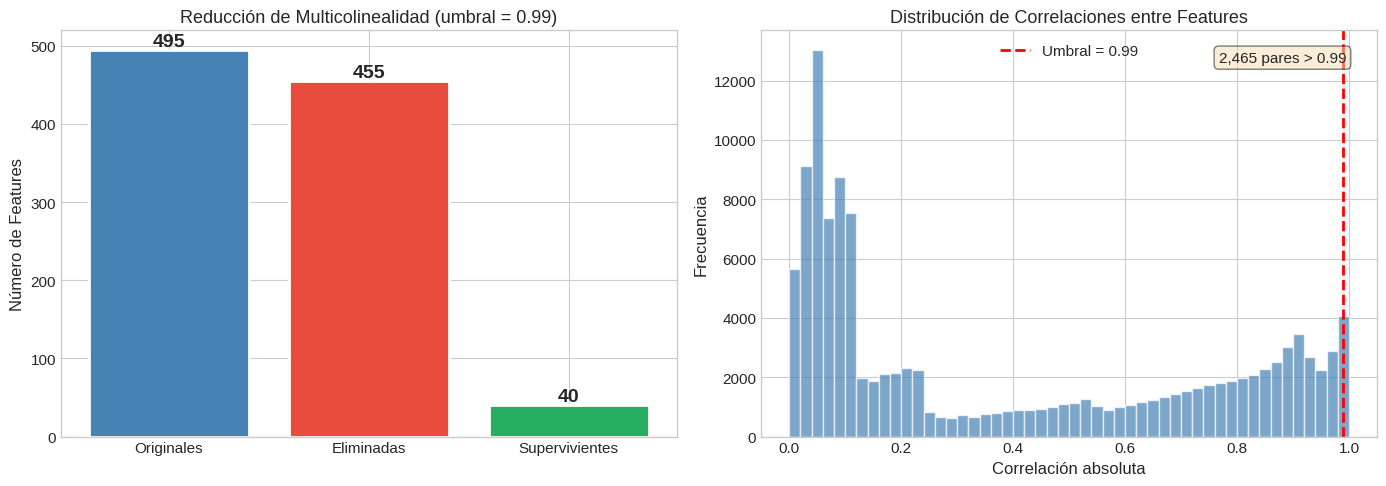


💡 De 122,265 pares posibles, 2,465 tienen correlación > 0.99


In [ ]:
# ============================================================
# VISUALIZAR LA REDUCCIÓN
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Barras comparativas
ax1 = axes[0]
categorias = ['Originales', 'Eliminadas', 'Supervivientes']
valores = [len(X_all.columns), len(features_a_eliminar), len(features_multicol)]
colores = ['steelblue', '#e74c3c', '#27ae60']

bars = ax1.bar(categorias, valores, color=colores, edgecolor='white', linewidth=2)
ax1.set_ylabel('Número de Features', fontsize=12)
ax1.set_title(f'Reducción de Multicolinealidad (umbral = {umbral_corr})', fontsize=13)

for bar, valor in zip(bars, valores):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f'{valor}', ha='center', fontsize=14, fontweight='bold')

# Gráfico 2: Distribución de correlaciones
ax2 = axes[1]

# Obtener correlaciones del triángulo superior (excluyendo diagonal)
corr_values = corr_matrix.values[upper_triangle]

ax2.hist(corr_values, bins=50, color='steelblue', edgecolor='white', alpha=0.7)
ax2.axvline(x=umbral_corr, color='red', linestyle='--', linewidth=2,
            label=f'Umbral = {umbral_corr}')
ax2.set_xlabel('Correlación absoluta', fontsize=12)
ax2.set_ylabel('Frecuencia', fontsize=12)
ax2.set_title('Distribución de Correlaciones entre Features', fontsize=13)
ax2.legend()

# Anotar cuántos pares superan el umbral
pares_alta_corr = (corr_values > umbral_corr).sum()
ax2.text(0.95, 0.95, f'{pares_alta_corr:,} pares > {umbral_corr}',
         transform=ax2.transAxes, ha='right', va='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

print(f"\n💡 De {len(corr_values):,} pares posibles, {pares_alta_corr:,} tienen correlación > {umbral_corr}")

In [ ]:
# ============================================================
# DEFINIR N (número objetivo de features)
# ============================================================

N = len(features_multicol)

print("=" * 60)
print(f"N = {N} features")
print("=" * 60)
print(f"\nEste será el número de features que seleccionaremos")
print(f"con cada uno de los métodos siguientes para poder compararlos.")

N = 40 features

Este será el número de features que seleccionaremos
con cada uno de los métodos siguientes para poder compararlos.


## 5. Método 2: RF Importance (Embedded)

Entrenamos un **RandomForestRegressor** con `Target_Return` y usamos las importancias para seleccionar las top N features.

```
RANDOM FOREST IMPORTANCE
═══════════════════════════════════════════════════════════════════

    ¿Cómo calcula RF la importancia de cada feature?
    
    1. Para cada árbol del bosque:
       → Mide cuánto REDUCE la impureza cada feature cuando se usa
       → Features que separan mejor los datos = más importantes
    
    2. Promedia las importancias de todos los árboles
    
    Ventajas:
    ✅ Considera interacciones entre features
    ✅ Captura relaciones no lineales
    ✅ Robusto (promedio de muchos árboles)
```

In [ ]:
# ============================================================
# CALCULAR IMPORTANCIAS CON RANDOM FOREST REGRESSOR
# ============================================================

print("Entrenando RandomForestRegressor para obtener importancias...")
print("(Usamos Target_Return porque es más informativo)")

inicio = time.time()

# Entrenar RF Regressor
rf_reg = RandomForestRegressor(
    n_estimators=100,
    max_depth=5,
    random_state=42,
    n_jobs=-1
)
rf_reg.fit(X_all, y_return)

tiempo_rf = time.time() - inicio
print(f"\n✅ Entrenado en {tiempo_rf:.2f} segundos")

# Obtener importancias
importancias_rf = pd.DataFrame({
    'Feature': X_all.columns,
    'Importance': rf_reg.feature_importances_
}).sort_values('Importance', ascending=False)

# Seleccionar top N
features_rf = importancias_rf.head(N)['Feature'].tolist()

print(f"\n📊 Top {N} features por RF Importance:")
print(importancias_rf.head(10).to_string(index=False))

Entrenando RandomForestRegressor para obtener importancias...
(Usamos Target_Return porque es más informativo)

✅ Entrenado en 53.19 segundos

📊 Top 40 features por RF Importance:
Feature  Importance
  CCI_6    0.053130
  CCI_2    0.036414
 ADX_44    0.027242
 ADX_92    0.025076
 CCI_85    0.024943
 CCI_39    0.024569
 CCI_19    0.022415
 CCI_34    0.021895
 ADX_85    0.017210
  CCI_3    0.016826


## 6. Método 3: SelectKBest con mutual_info_regression

La **información mutua** mide la dependencia entre variables, capturando relaciones **lineales y no lineales**.

```
mutual_info_regression (Información Mutua)
═══════════════════════════════════════════════════════════════════

    ¿Qué mide?
    
    → Cuánta INFORMACIÓN sobre el target obtenemos al conocer la feature
    → Basado en teoría de la información (entropía)
    
    MI(X, Y) = 0      → X e Y son independientes
    MI(X, Y) > 0      → X contiene información sobre Y
    MI(X, Y) alto     → X es muy predictiva de Y
    
    Ventajas:
    ✅ Captura relaciones NO LINEALES
    ✅ No asume ninguna forma funcional
    
    Limitaciones:
    ❌ Más lento que r_regression
    ❌ Puede ser ruidoso con pocas muestras
    ❌ Evalúa cada feature por separado
```

In [ ]:
# ============================================================
# SELECTKBEST CON mutual_info_regression
# ============================================================

print(f"Aplicando SelectKBest con mutual_info_regression (k={N})...")
print("(Este método es más lento porque estima densidades)")

inicio = time.time()

selector_mi = SelectKBest(score_func=mutual_info_regression, k=N)
selector_mi.fit(X_all, y_return)

tiempo_mi = time.time() - inicio
print(f"✅ Completado en {tiempo_mi:.2f} segundos")

# Obtener scores y features seleccionadas
scores_mi = pd.DataFrame({
    'Feature': X_all.columns,
    'MI_Score': selector_mi.scores_
}).sort_values('MI_Score', ascending=False)

features_mi = scores_mi.head(N)['Feature'].tolist()

print(f"\n📊 Top {N} features por mutual_info_regression:")
print(scores_mi.head(10).to_string(index=False))

Aplicando SelectKBest con mutual_info_regression (k=40)...
(Este método es más lento porque estima densidades)
✅ Completado en 8.66 segundos

📊 Top 40 features por mutual_info_regression:
Feature  MI_Score
 CCI_55  0.078190
 CCI_75  0.072432
 CCI_56  0.067568
 CCI_33  0.066231
 CCI_34  0.063214
 CCI_35  0.062298
 CCI_54  0.061404
 CCI_48  0.061137
 CCI_53  0.060910
 CCI_58  0.060179


## 7. Método 4: SelectKBest con r_regression

Este método usa directamente la **correlación de Pearson** entre cada feature y el target.

```
r_regression (Correlación de Pearson)
═══════════════════════════════════════════════════════════════════

    ¿Qué mide?
    
    → La correlación lineal directa entre feature y target
    → Valores entre -1 y +1
    
    r = +1    → Correlación positiva perfecta
    r = -1    → Correlación negativa perfecta
    r = 0     → Sin correlación lineal
    
    Nota: SelectKBest usa el VALOR ABSOLUTO de r para ranking
    
    Ventajas:
    ✅ Muy rápido
    ✅ Muy interpretable
    ✅ Conserva el signo (podemos ver si es positiva o negativa)
    
    Limitaciones:
    ❌ Solo relaciones lineales
```

In [ ]:
# ============================================================
# SELECTKBEST CON r_regression
# ============================================================

print(f"Aplicando SelectKBest con r_regression (k={N})...")

inicio = time.time()

selector_r = SelectKBest(score_func=r_regression, k=N)
selector_r.fit(X_all, y_return)

tiempo_r = time.time() - inicio
print(f"✅ Completado en {tiempo_r:.4f} segundos")

# Obtener scores y features seleccionadas
scores_r = pd.DataFrame({
    'Feature': X_all.columns,
    'R_Score': selector_r.scores_
}).sort_values('R_Score', ascending=False, key=abs)  # Ordenar por valor absoluto

features_r_reg = scores_r.head(N)['Feature'].tolist()

print(f"\n📊 Top {N} features por r_regression (ordenadas por |r|):")
print(scores_r.head(10).to_string(index=False))

Aplicando SelectKBest con r_regression (k=40)...
✅ Completado en 0.0174 segundos

📊 Top 40 features por r_regression (ordenadas por |r|):
Feature   R_Score
  ADX_5 -0.032529
  ADX_4 -0.032170
  ADX_6 -0.031523
  ADX_7 -0.030298
 ADX_87 -0.028887
 ADX_83 -0.028645
  ADX_3 -0.028424
 ADX_84 -0.028278
 ADX_91 -0.028122
  ADX_8 -0.028116


## 8. Comparar las Selecciones

Veamos cuánto coinciden los diferentes métodos.

In [ ]:
# ============================================================
# RESUMEN DE SELECCIONES
# ============================================================

# Diccionario con todas las selecciones
selecciones = {
    'Multicolinealidad': features_multicol,
    'RF_Importance': features_rf,
    'mutual_info': features_mi,
    'r_regression': features_r_reg
}

print("=" * 60)
print("RESUMEN DE MÉTODOS DE SELECCIÓN")
print("=" * 60)

for nombre, features in selecciones.items():
    print(f"\n{nombre}: {len(features)} features")
    print(f"   Primeras 5: {features[:5]}")

RESUMEN DE MÉTODOS DE SELECCIÓN

Multicolinealidad: 40 features
   Primeras 5: ['RSI_2', 'STOCH_2', 'WILLR_2', 'CCI_2', 'ADX_2']

RF_Importance: 40 features
   Primeras 5: ['CCI_6', 'CCI_2', 'ADX_44', 'ADX_92', 'CCI_85']

mutual_info: 40 features
   Primeras 5: ['CCI_55', 'CCI_75', 'CCI_56', 'CCI_33', 'CCI_34']

r_regression: 40 features
   Primeras 5: ['ADX_5', 'ADX_4', 'ADX_6', 'ADX_7', 'ADX_87']


In [ ]:
# ============================================================
# CALCULAR SOLAPAMIENTO ENTRE MÉTODOS
# ============================================================

print("\n" + "=" * 60)
print("SOLAPAMIENTO ENTRE MÉTODOS (features en común)")
print("=" * 60)

nombres = list(selecciones.keys())
n_metodos = len(nombres)

# Matriz de solapamiento
solapamiento = np.zeros((n_metodos, n_metodos))

for i, nombre1 in enumerate(nombres):
    for j, nombre2 in enumerate(nombres):
        comunes = len(set(selecciones[nombre1]) & set(selecciones[nombre2]))
        solapamiento[i, j] = comunes

# Mostrar como tabla
df_solap = pd.DataFrame(solapamiento.astype(int),
                        index=nombres,
                        columns=nombres)
print("\n")
print(df_solap.to_string())

print(f"\n💡 Cada método selecciona {N} features.")
print(f"   Los valores muestran cuántas features comparten dos métodos.")


SOLAPAMIENTO ENTRE MÉTODOS (features en común)


                   Multicolinealidad  RF_Importance  mutual_info  r_regression
Multicolinealidad                 40             15            0             6
RF_Importance                     15             40            7             9
mutual_info                        0              7           40             0
r_regression                       6              9            0            40

💡 Cada método selecciona 40 features.
   Los valores muestran cuántas features comparten dos métodos.


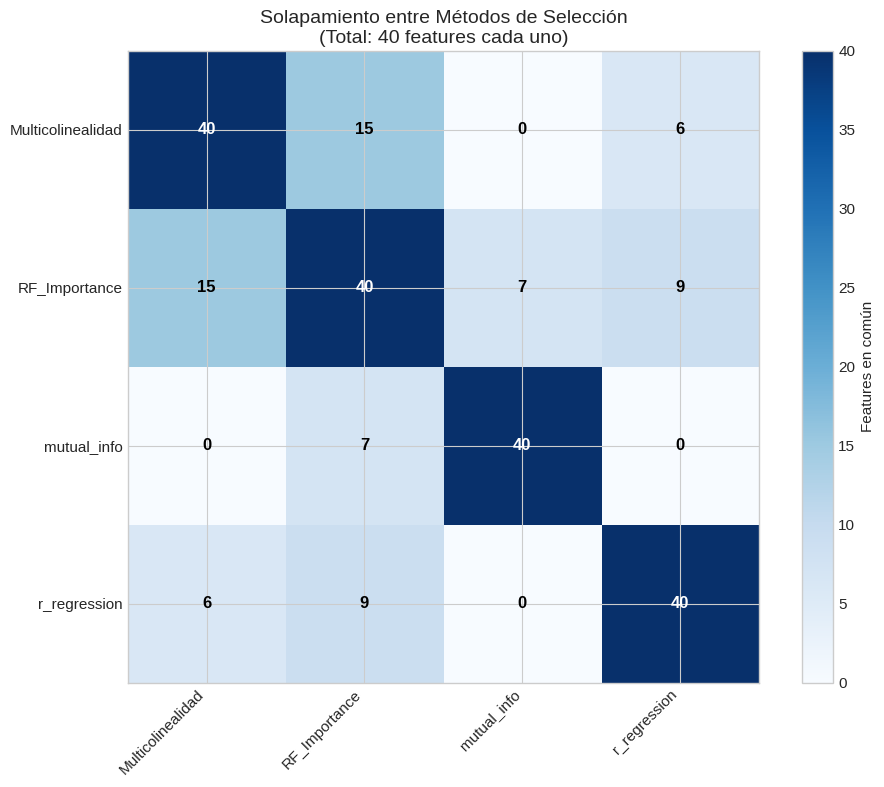


💡 Observaciones:
   • r_regression mide relación lineal (correlación de Pearson)
   • mutual_info puede diferir (captura relaciones no lineales)
   • RF_Importance considera interacciones entre features
   • Multicolinealidad es diferente (no mira el target)


In [ ]:
# ============================================================
# VISUALIZAR SOLAPAMIENTO
# ============================================================

fig, ax = plt.subplots(figsize=(10, 8))

# Heatmap
im = ax.imshow(solapamiento, cmap='Blues')

# Etiquetas
ax.set_xticks(range(n_metodos))
ax.set_yticks(range(n_metodos))
ax.set_xticklabels(nombres, rotation=45, ha='right')
ax.set_yticklabels(nombres)

# Añadir valores en las celdas
for i in range(n_metodos):
    for j in range(n_metodos):
        valor = int(solapamiento[i, j])
        color = 'white' if valor > N/2 else 'black'
        ax.text(j, i, str(valor), ha='center', va='center',
                color=color, fontsize=12, fontweight='bold')

ax.set_title(f'Solapamiento entre Métodos de Selección\n(Total: {N} features cada uno)', fontsize=14)

# Colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Features en común', fontsize=11)

plt.tight_layout()
plt.show()

print("\n💡 Observaciones:")
print("   • r_regression mide relación lineal (correlación de Pearson)")
print("   • mutual_info puede diferir (captura relaciones no lineales)")
print("   • RF_Importance considera interacciones entre features")
print("   • Multicolinealidad es diferente (no mira el target)")

## 9. Comparación de Modelos

Ahora entrenamos un **RandomForestClassifier** con cada conjunto de features y comparamos:
- Tiempo de entrenamiento
- Curvas de equity

```
CONFIGURACIÓN DEL EXPERIMENTO
═══════════════════════════════════════════════════════════════════

    Modelo: RandomForestClassifier
    • n_estimators = 500
    • max_depth = 3
    
    Conjuntos de features:
    1. Multicolinealidad (N features)
    2. RF_Importance (N features)
    3. mutual_info (N features)
    4. r_regression (N features)
    5. TODAS las features (baseline)
    
    Target: Target_Direccion (clasificación binaria)
```

In [ ]:
# ============================================================
# ENTRENAR MODELOS CON CADA CONJUNTO DE FEATURES
# ============================================================

# Añadir "todas las features" como baseline
selecciones_completas = selecciones.copy()
selecciones_completas['TODAS'] = list(X_all.columns)

# Almacenar resultados
resultados = {}

print("=" * 60)
print("ENTRENANDO MODELOS")
print("=" * 60)
print(f"\nConfiguración: RF(n_estimators=500, max_depth=3)")
print(f"Target: Target_Direccion (clasificación)")
print("\n")

for nombre, features in selecciones_completas.items():
    print(f"Entrenando con {nombre} ({len(features)} features)...", end=' ')

    # Preparar datos
    X_sel = df_clean[features]

    # Entrenar modelo
    inicio = time.time()

    rf = RandomForestClassifier(
        n_estimators=500,
        max_depth=3,
        random_state=42,
        n_jobs=-1
    )
    rf.fit(X_sel, y_direccion)

    tiempo = time.time() - inicio

    # Predicciones
    predicciones = rf.predict(X_sel)
    accuracy = (predicciones == y_direccion).mean()

    # Guardar resultados
    resultados[nombre] = {
        'n_features': len(features),
        'tiempo': tiempo,
        'accuracy': accuracy,
        'predicciones': predicciones,
        'modelo': rf
    }

    print(f"✅ {tiempo:.2f}s (Accuracy: {accuracy:.2%})")

print("\n" + "=" * 60)

ENTRENANDO MODELOS

Configuración: RF(n_estimators=500, max_depth=3)
Target: Target_Direccion (clasificación)


Entrenando con Multicolinealidad (40 features)... ✅ 3.97s (Accuracy: 59.94%)
Entrenando con RF_Importance (40 features)... ✅ 3.06s (Accuracy: 62.60%)
Entrenando con mutual_info (40 features)... ✅ 3.15s (Accuracy: 62.39%)
Entrenando con r_regression (40 features)... ✅ 4.16s (Accuracy: 58.34%)
Entrenando con TODAS (495 features)... ✅ 7.93s (Accuracy: 62.47%)



In [ ]:
# ============================================================
# TABLA COMPARATIVA DE RESULTADOS
# ============================================================

df_resultados = pd.DataFrame([
    {
        'Método': nombre,
        'N_Features': res['n_features'],
        'Tiempo (s)': res['tiempo'],
        'Accuracy': res['accuracy']
    }
    for nombre, res in resultados.items()
]).sort_values('Accuracy', ascending=False)

print("\n" + "=" * 60)
print("COMPARATIVA DE RESULTADOS")
print("=" * 60)
print("\n")

# Formatear para mostrar
df_display = df_resultados.copy()
df_display['Tiempo (s)'] = df_display['Tiempo (s)'].apply(lambda x: f"{x:.2f}")
df_display['Accuracy'] = df_display['Accuracy'].apply(lambda x: f"{x:.2%}")

print(df_display.to_string(index=False))


COMPARATIVA DE RESULTADOS


           Método  N_Features Tiempo (s) Accuracy
    RF_Importance          40       3.06   62.60%
            TODAS         495       7.93   62.47%
      mutual_info          40       3.15   62.39%
Multicolinealidad          40       3.97   59.94%
     r_regression          40       4.16   58.34%


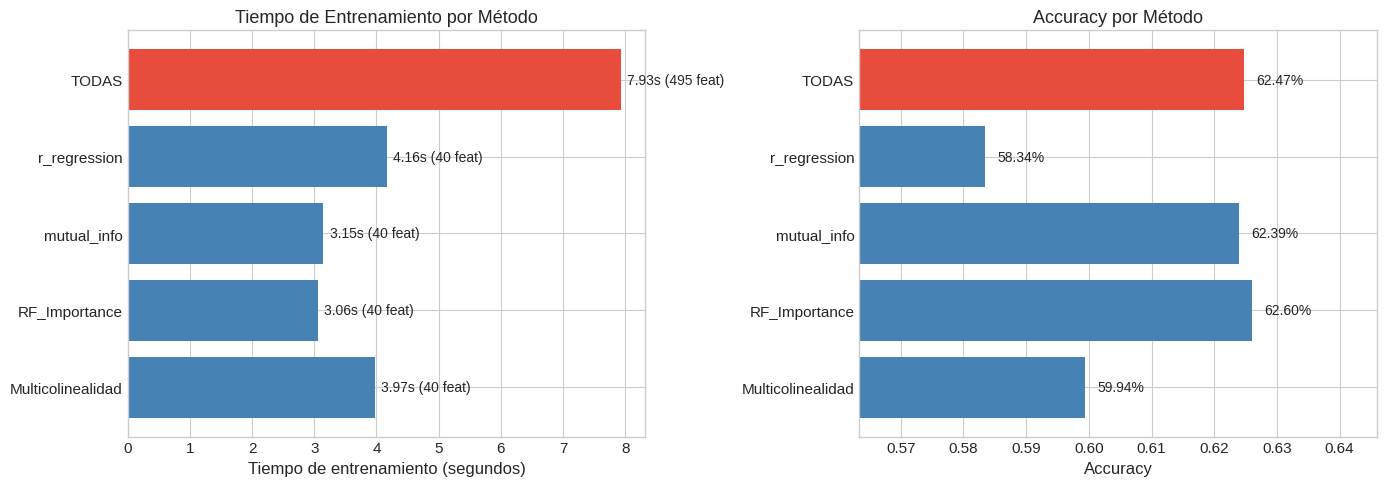


💡 Comparando con usar TODAS las features:
   Multicolinealidad: 2.0x más rápido, -2.53% accuracy
   RF_Importance: 2.6x más rápido, +0.12% accuracy
   mutual_info: 2.5x más rápido, -0.08% accuracy
   r_regression: 1.9x más rápido, -4.14% accuracy


In [ ]:
# ============================================================
# VISUALIZAR TIEMPOS Y ACCURACY
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

metodos = list(resultados.keys())
tiempos = [resultados[m]['tiempo'] for m in metodos]
accuracies = [resultados[m]['accuracy'] for m in metodos]
n_features = [resultados[m]['n_features'] for m in metodos]

# Colores (destacar TODAS)
colores = ['steelblue'] * (len(metodos) - 1) + ['#e74c3c']

# Gráfico 1: Tiempos de entrenamiento
ax1 = axes[0]
bars1 = ax1.barh(metodos, tiempos, color=colores)
ax1.set_xlabel('Tiempo de entrenamiento (segundos)', fontsize=12)
ax1.set_title('Tiempo de Entrenamiento por Método', fontsize=13)

for bar, t, n in zip(bars1, tiempos, n_features):
    ax1.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
             f'{t:.2f}s ({n} feat)', va='center', fontsize=10)

# Gráfico 2: Accuracy
ax2 = axes[1]
bars2 = ax2.barh(metodos, accuracies, color=colores)
ax2.set_xlabel('Accuracy', fontsize=12)
ax2.set_title('Accuracy por Método', fontsize=13)
ax2.set_xlim(min(accuracies) - 0.02, max(accuracies) + 0.02)

for bar, acc in zip(bars2, accuracies):
    ax2.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
             f'{acc:.2%}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

# Calcular speedup
tiempo_todas = resultados['TODAS']['tiempo']
print(f"\n💡 Comparando con usar TODAS las features:")
for nombre in metodos[:-1]:
    speedup = tiempo_todas / resultados[nombre]['tiempo']
    diff_acc = resultados[nombre]['accuracy'] - resultados['TODAS']['accuracy']
    print(f"   {nombre}: {speedup:.1f}x más rápido, {diff_acc:+.2%} accuracy")

## 10. Curvas de Equity

In [ ]:
# ============================================================
# CALCULAR CURVAS DE EQUITY
# ============================================================

# Para cada método, calcular retornos del sistema
equity_curves = {}

for nombre, res in resultados.items():
    # Señal: 1 si predice SUBE, -1 si predice BAJA
    señal = np.where(res['predicciones'] == 1, 1, -1)

    # Retorno del sistema = señal * retorno real
    retornos_sistema = señal * df_clean['Target_Return'].values

    # Equity curve (retorno acumulado)
    equity = (1 + retornos_sistema).cumprod()
    equity_curves[nombre] = equity

# Buy & Hold como referencia
equity_bh = (1 + df_clean['Target_Return'].values).cumprod()

print("✅ Curvas de equity calculadas")

✅ Curvas de equity calculadas


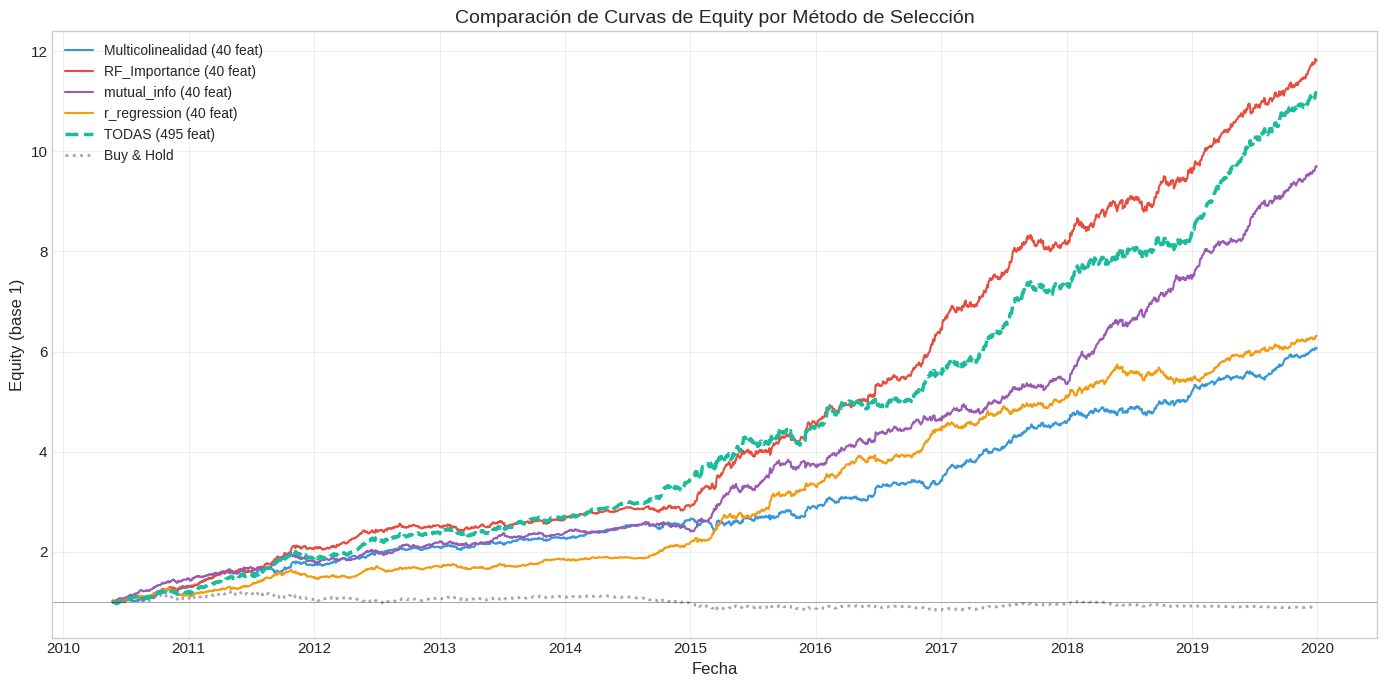

In [ ]:
# ============================================================
# VISUALIZAR CURVAS DE EQUITY
# ============================================================

fig, ax = plt.subplots(figsize=(14, 7))

# Colores para cada método
colores_equity = {
    'Multicolinealidad': '#3498db',
    'RF_Importance': '#e74c3c',
    'mutual_info': '#9b59b6',
    'r_regression': '#f39c12',
    'TODAS': '#1abc9c'
}

# Plotear cada curva
fechas = df_clean.index

for nombre, equity in equity_curves.items():
    linestyle = '--' if nombre == 'TODAS' else '-'
    linewidth = 2.5 if nombre == 'TODAS' else 1.5
    ax.plot(fechas, equity, label=f'{nombre} ({resultados[nombre]["n_features"]} feat)',
            color=colores_equity[nombre], linestyle=linestyle, linewidth=linewidth)

# Buy & Hold
ax.plot(fechas, equity_bh, label='Buy & Hold', color='gray',
        linestyle=':', linewidth=2, alpha=0.7)

ax.set_xlabel('Fecha', fontsize=12)
ax.set_ylabel('Equity (base 1)', fontsize=12)
ax.set_title('Comparación de Curvas de Equity por Método de Selección', fontsize=14)
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)

# Línea horizontal en 1
ax.axhline(y=1, color='black', linestyle='-', linewidth=0.5, alpha=0.5)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# MÉTRICAS DE RENDIMIENTO
# ============================================================

print("=" * 70)
print("MÉTRICAS DE RENDIMIENTO")
print("=" * 70)
print(f"\n{'Método':<20} {'Features':>10} {'Equity Final':>15} {'Retorno Total':>15}")
print("-" * 70)

for nombre, equity in equity_curves.items():
    equity_final = equity[-1]
    retorno_total = (equity_final - 1) * 100
    n_feat = resultados[nombre]['n_features']
    print(f"{nombre:<20} {n_feat:>10} {equity_final:>15.4f} {retorno_total:>14.2f}%")

# Buy & Hold
print("-" * 70)
equity_bh_final = equity_bh[-1]
retorno_bh = (equity_bh_final - 1) * 100
print(f"{'Buy & Hold':<20} {'-':>10} {equity_bh_final:>15.4f} {retorno_bh:>14.2f}%")
print("=" * 70)

MÉTRICAS DE RENDIMIENTO

Método                 Features    Equity Final   Retorno Total
----------------------------------------------------------------------
Multicolinealidad            40          6.0632         506.32%
RF_Importance                40         11.8105        1081.05%
mutual_info                  40          9.6940         869.40%
r_regression                 40          6.3157         531.57%
TODAS                       495         11.1581        1015.81%
----------------------------------------------------------------------
Buy & Hold                    -          0.9023          -9.77%


## ⚠️ Advertencia Importante

```
ERROR METODOLÓGICO (que corregiremos en la próxima sesión)
═══════════════════════════════════════════════════════════════════

En esta sesión hemos cometido VARIOS errores metodológicos:

    1. SELECCIÓN DE FEATURES CON TODOS LOS DATOS
       ─────────────────────────────────────────
       Hemos usado TODOS los datos para calcular correlaciones,
       importancias y scores de SelectKBest.
       
       → Esto "filtra" información del futuro al proceso de selección
       → Las features seleccionadas están sesgadas hacia este dataset

    2. ENTRENAMIENTO Y EVALUACIÓN CON LOS MISMOS DATOS
       ───────────────────────────────────────────────
       Igual que en sesiones anteriores, evaluamos en datos de
       entrenamiento.
       
       → El accuracy y las curvas de equity son OPTIMISTAS
       → No sabemos cómo funcionará en datos nuevos

    3. RIESGO DE SOBREAJUSTE MÚLTIPLE
       ─────────────────────────────
       Al probar 4 métodos y compararlos, estamos "eligiendo" el mejor
       para ESTE dataset específico.
       
       → El mejor método aquí puede no ser el mejor en general


SOLUCIÓN: Partición In-Sample / Out-of-Sample (Sesión 8)
═══════════════════════════════════════════════════════════════════

    En la próxima sesión aprenderemos a:
    
    • Dividir los datos en entrenamiento (IS) y test (OOS)
    • Hacer la selección de features SOLO con datos IS
    • Evaluar el rendimiento SOLO con datos OOS
    • Obtener métricas REALISTAS del sistema
```

---

## Resumen de la Sesión

En esta sesión hemos aprendido:

✅ **Por qué seleccionar variables:** Maldición de la dimensionalidad, ruido, sobreajuste

✅ **Tipos de métodos:** Filtro, Wrapper, Embedded

✅ **Reducir multicolinealidad:** Eliminar features con correlación > 0.99

✅ **RF Importance:** Método embedded que considera interacciones

✅ **SelectKBest:** Métodos de filtro (mutual_info, r_regression)

✅ **Target continuo vs discreto:** Usar Target_Return para selección (más informativo)

✅ **Trade-off features/tiempo:** Menos features → Entrenamiento más rápido

### Próxima Sesión

En la **Sesión 8 (3 de febrero)** veremos **Partición In-Sample / Out-of-Sample**, donde aprenderemos:

- **División temporal:** No mezclar pasado con futuro
- **Evaluación honesta:** Probar en datos nunca vistos
- **Pipeline correcto:** Selección de features solo con datos de entrenamiento

Esto es FUNDAMENTAL para obtener métricas realistas de cualquier sistema de trading.